# TENG Gesture Recognition — Results Visualization

## 初始化：加载已保存的推断结果

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
from IPython.display import display, SVG

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              f1_score, precision_score, recall_score)

PROJECT_ROOT = Path('../').resolve()
SVG_DIR = PROJECT_ROOT / 'svg'
SVG_DIR.mkdir(exist_ok=True)

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['svg.fonttype'] = 'none'

# Load saved inference results — no re-inference needed
pred_all = np.load(PROJECT_ROOT / 'checkpoints/test_pred.npy')
y_te     = np.load(PROJECT_ROOT / 'checkpoints/test_true.npy')
envs_te  = np.load(PROJECT_ROOT / 'checkpoints/test_envs.npy', allow_pickle=True)

GESTURE_NAMES = ['1','2','3','4','5','go_the_way','ok','sc','stop','wave']
ENVS       = ['base','wind_noise','uv_radiation']
ENV_LABELS = {'base':'Normal','wind_noise':'Wind Noise','uv_radiation':'UV Radiation'}
COLORS     = {'base':'#4C72B0','wind_noise':'#DD8452','uv_radiation':'#55A868'}

# build label_order from y_te / pred_all unique labels (sorted)
all_labels = np.unique(y_te)
label_order = list(all_labels)  # numeric labels 0-9

print(f'Test samples: {len(y_te)}  |  Overall accuracy: {accuracy_score(y_te, pred_all):.4f}')
from collections import Counter
for env in ENVS:
    m = envs_te == env
    print(f'  {ENV_LABELS[env]:15s}: n={m.sum():3d}, acc={accuracy_score(y_te[m], pred_all[m]):.4f}')

Test samples: 232  |  Overall accuracy: 0.9052
  Normal         : n=187, acc=0.9091
  Wind Noise     : n= 35, acc=0.9143
  UV Radiation   : n= 10, acc=0.8000


## 1. Per-Gesture Accuracy by Scene

每个场景下各手势的分类准确率柱状图，红色虚线为该场景整体准确率。

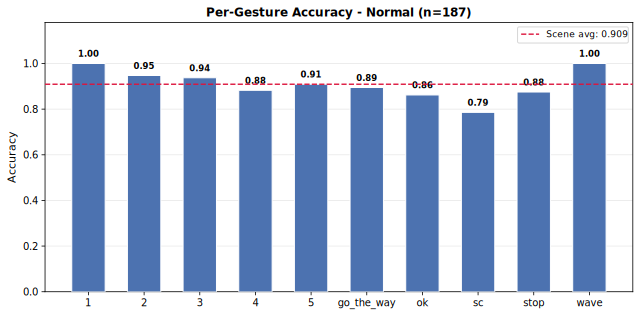

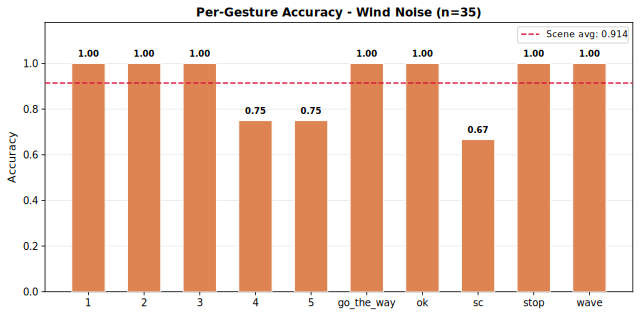

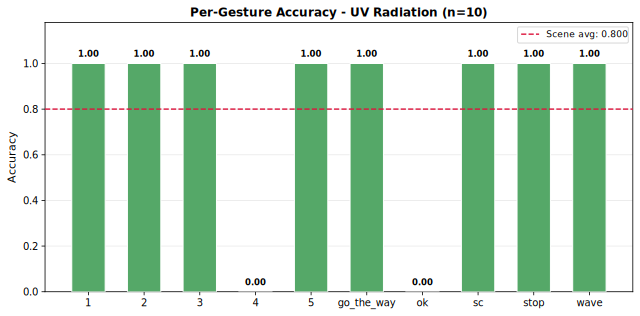

In [2]:
for env in ENVS:
    mask = envs_te == env
    y_env = y_te[mask]; p_env = pred_all[mask]; n_env = mask.sum()
    per_cls = []
    for lbl in label_order:
        m = y_env == lbl
        per_cls.append(accuracy_score(y_env[m], p_env[m]) if m.sum() > 0 else float('nan'))
    overall_env = accuracy_score(y_env, p_env)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(GESTURE_NAMES))
    bars = ax.bar(x, per_cls, color=COLORS[env], edgecolor='white', width=0.6, zorder=3)
    ax.axhline(overall_env, color='crimson', linestyle='--', linewidth=1.4,
               label=f'Scene avg: {overall_env:.3f}', zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(GESTURE_NAMES, fontsize=10)
    ax.set_ylim(0, 1.18); ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'Per-Gesture Accuracy - {ENV_LABELS[env]}  (n={n_env})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3, zorder=0)
    for bar, acc in zip(bars, per_cls):
        if acc == acc:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{acc:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    fig.tight_layout()
    p = SVG_DIR / f'per_gesture_acc_{env}.svg'
    fig.savefig(p, format='svg', bbox_inches='tight'); plt.close(fig)
    display(SVG(filename=str(p)))

## 2. Confusion Matrices by Scene

每个场景的混淆矩阵，左侧为数量，右侧为行归一化百分比。

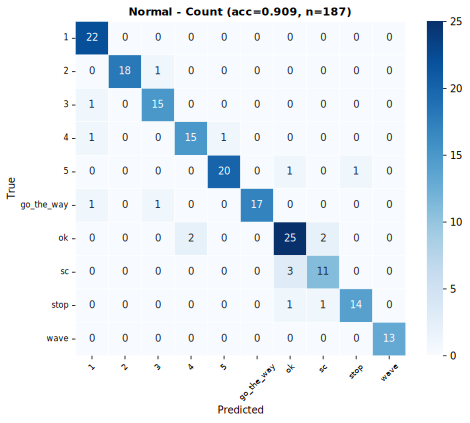

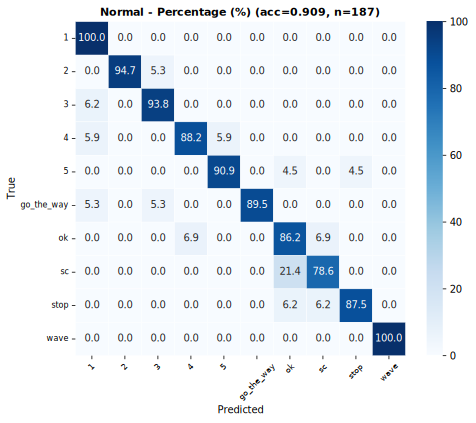

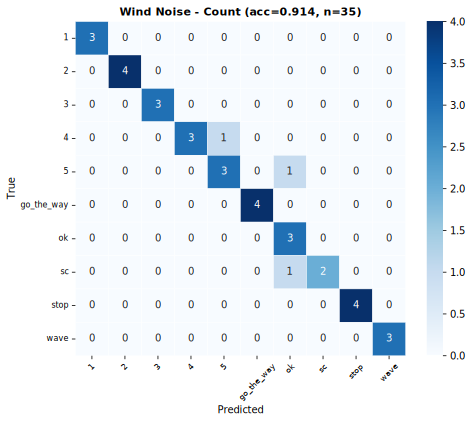

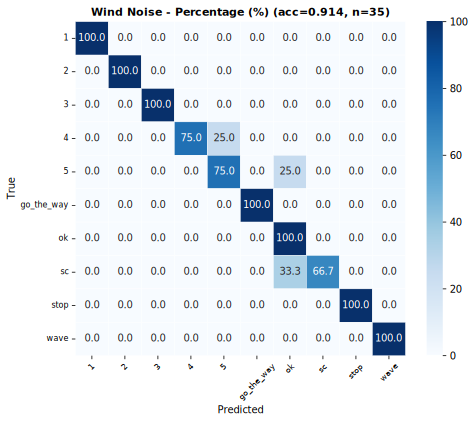

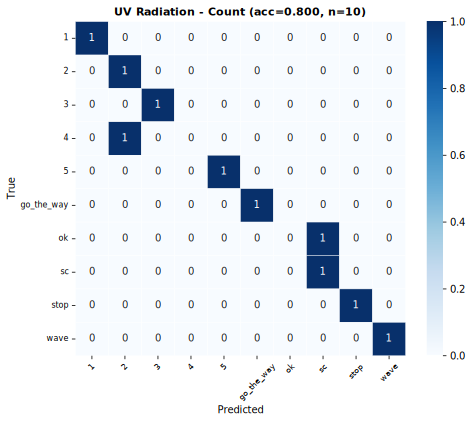

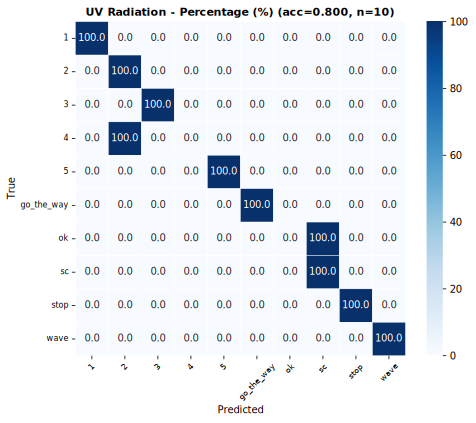

In [3]:
for env in ENVS:
    mask = envs_te == env
    y_env = y_te[mask]; p_env = pred_all[mask]
    n_env = mask.sum(); acc_env = accuracy_score(y_env, p_env)
    cm_c = confusion_matrix(y_env, p_env, labels=label_order)
    cm_p = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True) * 100

    for kind, (cm, fmt, vmax, label) in [
        ('count', (cm_c, 'd',   None,  'Count')),
        ('pct',   (cm_p, '.1f', 100.0, 'Percentage (%)')),
    ]:
        fig, ax = plt.subplots(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES,
                    vmin=0, vmax=vmax, linewidths=0.4, linecolor='white', ax=ax)
        ax.set_title(f'{ENV_LABELS[env]} - {label}  (acc={acc_env:.3f}, n={n_env})',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0,  labelsize=8)
        fig.tight_layout()
        p = SVG_DIR / f'cm_{kind}_{env}.svg'
        fig.savefig(p, format='svg', bbox_inches='tight'); plt.close(fig)
        display(SVG(filename=str(p)))

## 3. Score Tables

四张表格分别展示 Accuracy、Recall、F1、Precision。行为10个手势+汇总，列为三个场景+汇总。

In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

def compute_table(metric_fn, y_true, y_pred, label_order, gesture_names, envs_te, env_keys, env_labels):
    rows = {}
    for g, lbl in zip(gesture_names, label_order):
        row = {}
        for ek, el in zip(env_keys, env_labels):
            if ek == 'overall':
                yt, yp = y_true, y_pred
            else:
                m = envs_te == ek; yt, yp = y_true[m], y_pred[m]
            gm = yt == lbl
            if gm.sum() == 0:
                row[el] = float('nan')
            else:
                yb = (yt == lbl).astype(int); pb = (yp == lbl).astype(int)
                row[el] = metric_fn(yb, pb)
        rows[g] = row
    # Overall row
    overall = {}
    for ek, el in zip(env_keys, env_labels):
        if ek == 'overall':
            yt, yp = y_true, y_pred
        else:
            m = envs_te == ek; yt, yp = y_true[m], y_pred[m]
        overall[el] = metric_fn(yt, yp, average=True)
    rows['Overall'] = overall
    return pd.DataFrame(rows, index=list(env_labels)).T

env_keys   = ENVS + ['overall']
env_labels = [ENV_LABELS[e] for e in ENVS] + ['Overall']

def acc_fn(a, b, average=False):
    return accuracy_score(a, b) if average else accuracy_score(a[a==1], b[a==1]) if (a==1).sum() > 0 else float('nan')

def rec_fn(a, b, average=False):
    return recall_score(a, b, average='macro', zero_division=0) if average else recall_score(a, b, zero_division=0)

def f1_fn(a, b, average=False):
    return f1_score(a, b, average='macro', zero_division=0) if average else f1_score(a, b, zero_division=0)

def prec_fn(a, b, average=False):
    return precision_score(a, b, average='macro', zero_division=0) if average else precision_score(a, b, zero_division=0)

for title, fn in [('Accuracy', acc_fn), ('Recall', rec_fn), ('F1', f1_fn), ('Precision', prec_fn)]:
    df = compute_table(fn, y_te, pred_all, label_order, GESTURE_NAMES, envs_te, env_keys, env_labels)
    print(f'### {title}')
    display(df.style.format('{:.3f}', na_rep='N/A').set_caption(title))


### Accuracy


,Normal,Wind Noise,UV Radiation,Overall
1,1.000,1.000,1.000,1.000
2,0.947,1.000,1.000,0.958
3,0.938,1.000,1.000,0.950
4,0.882,0.750,0.000,0.818
5,0.909,0.750,1.000,0.889
go_the_way,0.895,1.000,1.000,0.917
ok,0.862,1.000,0.000,0.848
sc,0.786,0.667,1.000,0.778
stop,0.875,1.000,1.000,0.905
wave,1.000,1.000,1.000,1.000


### Recall


,Normal,Wind Noise,UV Radiation,Overall
1,1.000,1.000,1.000,1.000
2,0.947,1.000,1.000,0.958
3,0.938,1.000,1.000,0.950
4,0.882,0.750,0.000,0.818
5,0.909,0.750,1.000,0.889
go_the_way,0.895,1.000,1.000,0.917
ok,0.862,1.000,0.000,0.848
sc,0.786,0.667,1.000,0.778
stop,0.875,1.000,1.000,0.905
wave,1.000,1.000,1.000,1.000


### F1


,Normal,Wind Noise,UV Radiation,Overall
1,0.936,1.000,1.000,0.945
2,0.973,1.000,0.667,0.958
3,0.909,1.000,1.000,0.927
4,0.882,0.857,0.000,0.857
5,0.930,0.750,1.000,0.906
go_the_way,0.944,1.000,1.000,0.957
ok,0.847,0.750,0.000,0.824
sc,0.786,0.800,0.667,0.778
stop,0.903,1.000,1.000,0.927
wave,1.000,1.000,1.000,1.000


### Precision


,Normal,Wind Noise,UV Radiation,Overall
1,0.880,1.000,1.000,0.897
2,1.000,1.000,0.500,0.958
3,0.882,1.000,1.000,0.905
4,0.882,1.000,0.000,0.900
5,0.952,0.750,1.000,0.923
go_the_way,1.000,1.000,1.000,1.000
ok,0.833,0.600,0.000,0.800
sc,0.786,1.000,0.500,0.778
stop,0.933,1.000,1.000,0.950
wave,1.000,1.000,1.000,1.000
